In [1]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect(r"../data/data.sqlite")

cleaned_co2e_data = pd.read_sql_query("SELECT * FROM co2e_price_development", conn, index_col="index", parse_dates=["date"])
global_ghg_emissions = pd.read_sql_query("SELECT * FROM global_ghg_emissions", conn, index_col="index")

URL_GLOBAL_GHG_EMSISSIONS = "https://edgar.jrc.ec.europa.eu/booklet/EDGARv8.0_FT2022_GHG_booklet_2023.xlsx"
global_ghg_emissions_file = pd.ExcelFile(URL_GLOBAL_GHG_EMSISSIONS)
global_ghg_emissions_raw = pd.read_excel(global_ghg_emissions_file, sheet_name="GHG_by_sector_and_country")
global_ghg_emissions_sectors = global_ghg_emissions_raw.dropna()

cleaned_co2e_data.head()

,date,price
index,,
0,2008-01-03,23.54
1,2008-01-04,23.55
2,2008-01-07,23.66
3,2008-01-08,23.70
4,2008-01-09,23.42


# Analysis

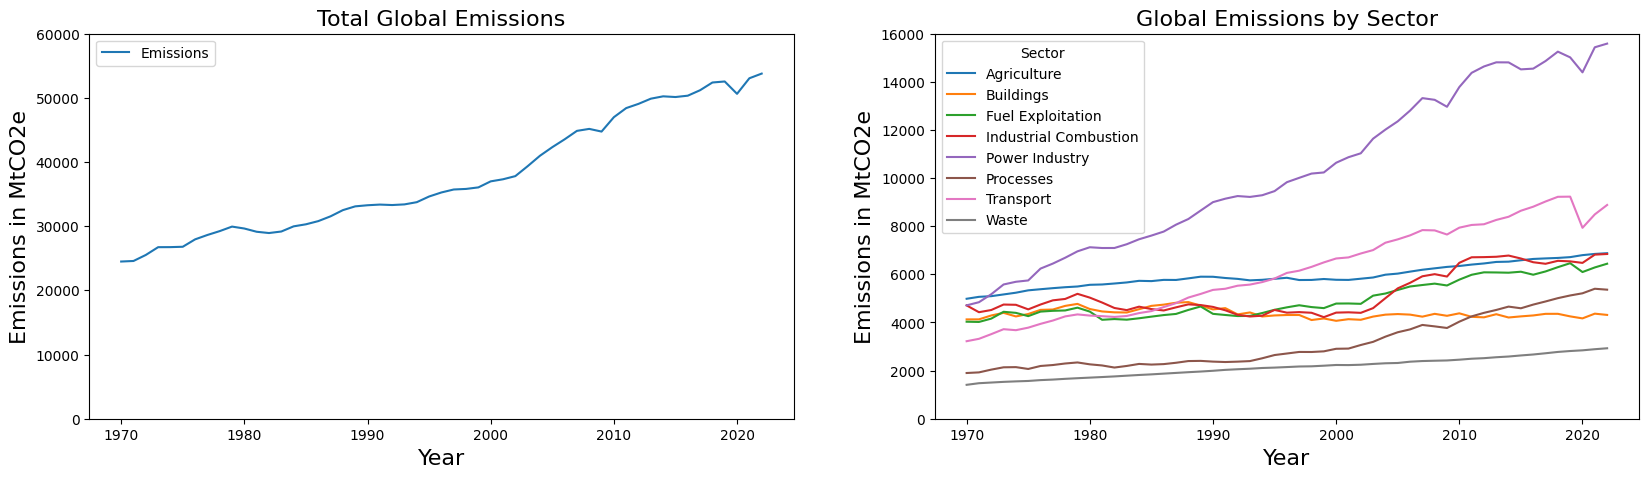

In [34]:
### PLOT FOR LATEX DOCUMENT

total_global_emissions = global_ghg_emissions[global_ghg_emissions["Country"] == "GLOBAL TOTAL"].T
total_global_emissions.columns = ["Emissions"]
total_global_emissions_per_sector = global_ghg_emissions_sectors[global_ghg_emissions_sectors["Country"] != "GLOBAL TOTAL"].groupby("Sector").sum().T

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

total_global_emissions.iloc[2:, :].plot(
    ax=axes[0], 
    kind="line", 
    title="Total Global Emissions",
    ylabel="Emissions in MtCO2e", 
    xlabel="Year",
    ylim=[0, 60000]
)
axes[0].title.set_fontsize(16)
axes[0].yaxis.get_label().set_fontsize(16)
axes[0].xaxis.get_label().set_fontsize(16)
axes[0].legend(loc="upper left")

total_global_emissions_fig = total_global_emissions_per_sector.iloc[3:, :].plot(
    ax=axes[1], 
    kind="line", 
    title="Global Emissions by Sector", 
    ylabel="Emissions in MtCO2e", 
    xlabel="Year",
    ylim=[0, 16000]
).get_figure()
axes[1].title.set_fontsize(16)
axes[1].yaxis.get_label().set_fontsize(16)
axes[1].xaxis.get_label().set_fontsize(16)

total_global_emissions_fig.savefig("global_emssions.pdf", format="pdf", bbox_inches="tight")
plt.rcdefaults()

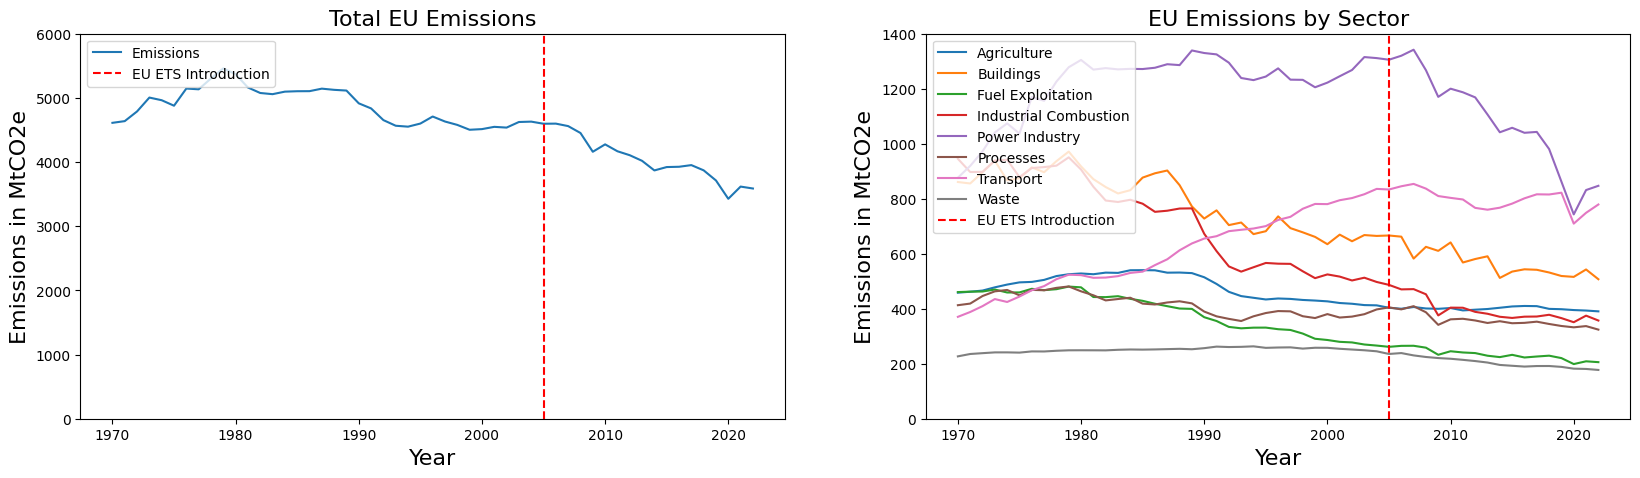

In [35]:
### PLOT FOR LATEX DOCUMENT

total_eu_emissions = global_ghg_emissions[global_ghg_emissions["Country"] == "EU27"].T
total_eu_emissions.columns = ["Emissions"]

eu_emissions_per_sector = global_ghg_emissions_sectors[global_ghg_emissions_sectors["Country"] == "EU27"].groupby("Sector").sum().T
eu_emissions_per_sector = eu_emissions_per_sector.iloc[3:, :]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

total_eu_emissions_fig = total_eu_emissions.iloc[2:, :].plot(
    ax=axes[0], 
    kind="line", 
    title="Total EU Emissions", 
    ylabel="Emissions in MtCO2e", 
    xlabel="Year",
    ylim=[0, 6000],
).get_figure()
axes[0].title.set_fontsize(16)
axes[0].yaxis.get_label().set_fontsize(16)
axes[0].xaxis.get_label().set_fontsize(16)
axes[0].axvline(x=35, color='r', label='EU ETS Introduction', ls='--')
axes[0].legend(loc="upper left")

eu_emissions_per_sector_fig = eu_emissions_per_sector.iloc[0:, :].plot(
    ax=axes[1], 
    kind="line", 
    title="EU Emissions by Sector", 
    ylabel="Emissions in MtCO2e", 
    xlabel="Year",
    ylim=[0, 1400]
).get_figure()
axes[1].title.set_fontsize(16)
axes[1].yaxis.get_label().set_fontsize(16)
axes[1].xaxis.get_label().set_fontsize(16)
axes[1].axvline(x=35, color='r', label='EU ETS Introduction', ls='--')
axes[1].legend(loc="upper left")

eu_emissions_per_sector_fig.savefig("eu_emissions.pdf", format="pdf", bbox_inches="tight")
plt.rcdefaults()

In [36]:
filter_total = global_ghg_emissions_sectors[global_ghg_emissions_sectors["Country"] == "EU27"]
all_sectors = filter_total.groupby("Sector",as_index=True).sum().T.iloc[3:,:]
all_sectors.reset_index(inplace=True)
all_sectors["index"]=pd.to_datetime(all_sectors["index"].apply(lambda x: f"{x}-01-01"))
all_sectors["Power Industry"]=pd.to_numeric(all_sectors["Power Industry"])
all_sectors.head()

Sector,index,Agriculture,Buildings,Fuel Exploitation,Industrial Combustion,Power Industry,Processes,Transport,Waste
0,1970-01-01,458.372406,860.748074,460.547605,945.14193,876.472407,412.79121,370.472098,226.780034
1,1971-01-01,461.764697,855.463665,462.047587,897.134309,919.289346,418.670172,388.100639,235.380683
2,1972-01-01,466.054428,896.518829,462.571915,897.680804,972.196282,446.14038,409.372077,238.398653
3,1973-01-01,477.769309,938.226483,469.768264,938.883123,1040.879558,463.166446,435.117449,241.214425
4,1974-01-01,487.811111,866.876232,458.997964,941.806063,1073.974143,468.241824,424.544647,241.265098


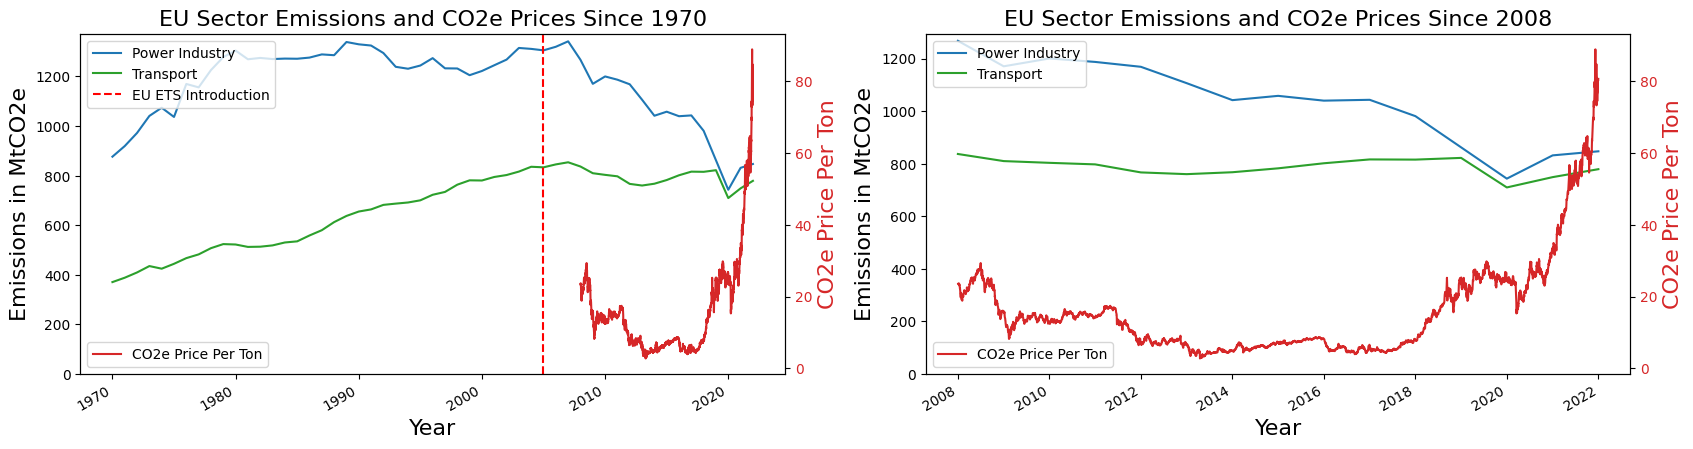

In [37]:
### PLOT FOR LATEX DOCUMENT

df_emissions = pd.DataFrame({
    'date': all_sectors["index"],
    'emission': all_sectors["Power Industry"]
})

df_prices = pd.DataFrame({
    'date':cleaned_co2e_data['date'],
    'price': cleaned_co2e_data['price'],
})

df_merged = pd.merge(df_prices, df_emissions, on='date', how='outer')
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

axes[0].title.set_fontsize(16)
axes[0].yaxis.get_label().set_fontsize(16)
axes[0].xaxis.get_label().set_fontsize(16)

# Plot emission data since 1970
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Emissions in MtCO2e')
emission_mask = all_sectors.loc[all_sectors["index"]>="1970-01-01"]["Power Industry"]
date_mask = all_sectors.loc[all_sectors["index"]>="1970-01-01"]["index"]
axes[0].plot(date_mask, emission_mask, color='tab:blue', label="Power Industry")
axes[0].tick_params(axis='y')
axes[0].set_ylim(0)
axes[0].set_title("EU Sector Emissions and CO2e Prices Since 1970")
axes[0].title.set_fontsize(16)

emission_mask = all_sectors.loc[all_sectors["index"]>="1970-01-01"]["Transport"]
date_mask = all_sectors.loc[all_sectors["index"]>="1970-01-01"]["index"]
axes[0].plot(date_mask, emission_mask, color='tab:green', label="Transport")

# Create a second y-axis for the price data
ax2 = axes[0].twinx()  
ax2.set_ylabel('CO2e Price Per Ton', color='tab:red')  
price_mask = cleaned_co2e_data.loc[cleaned_co2e_data['date']<"2022-01-02"]['price']
date_price_mask = cleaned_co2e_data.loc[cleaned_co2e_data['date']<"2022-01-02"]['date']
ax2.plot(date_price_mask, price_mask, color='tab:red', label="CO2e Price Per Ton")
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.yaxis.get_label().set_fontsize(16)
ax2.xaxis.get_label().set_fontsize(16)

axes[0].axvline(35*365, color='r', label='EU ETS Introduction', ls='--')
ax2.legend(loc="lower left")
axes[0].legend(loc="upper left")

axes[1].title.set_fontsize(16)
axes[1].yaxis.get_label().set_fontsize(16)
axes[1].xaxis.get_label().set_fontsize(16)

# Plot emission data since 2005
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Emissions in MtCO2e')
emission_mask = all_sectors.loc[all_sectors["index"]>="2008-01-01"]["Power Industry"]
date_mask = all_sectors.loc[all_sectors["index"]>="2008-01-01"]["index"]
axes[1].plot(date_mask, emission_mask, color='tab:blue', label="Power Industry")
axes[1].tick_params(axis='y')
axes[1].set_ylim(0)
axes[1].set_title("EU Sector Emissions and CO2e Prices Since 2008")
axes[1].title.set_fontsize(16)

emission_mask = all_sectors.loc[all_sectors["index"]>="2008-01-01"]["Transport"]
date_mask = all_sectors.loc[all_sectors["index"]>="2008-01-01"]["index"]
axes[1].plot(date_mask, emission_mask, color='tab:green', label="Transport")

# Create a second y-axis for the price data
ax2 = axes[1].twinx()  
ax2.set_ylabel('CO2e Price Per Ton', color='tab:red')  
price_mask = cleaned_co2e_data.loc[cleaned_co2e_data['date']<"2022-01-02"]['price']
date_price_mask = cleaned_co2e_data.loc[cleaned_co2e_data['date']<"2022-01-02"]['date']
ax2.plot(date_price_mask, price_mask, color='tab:red', label="CO2e Price Per Ton")
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.yaxis.get_label().set_fontsize(16)
ax2.xaxis.get_label().set_fontsize(16)

ax2.legend(loc="lower left")
axes[1].legend(loc="upper left")

fig.autofmt_xdate()
plt.show()

fig.savefig("emissions_vs_coe2_price.pdf", format="pdf", bbox_inches="tight")

/tmp/ipykernel_118270/611473403.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  head_5['Change in %'] = (head_5["2022"] - head_5["2005"]) / head_5["2005"] * 100


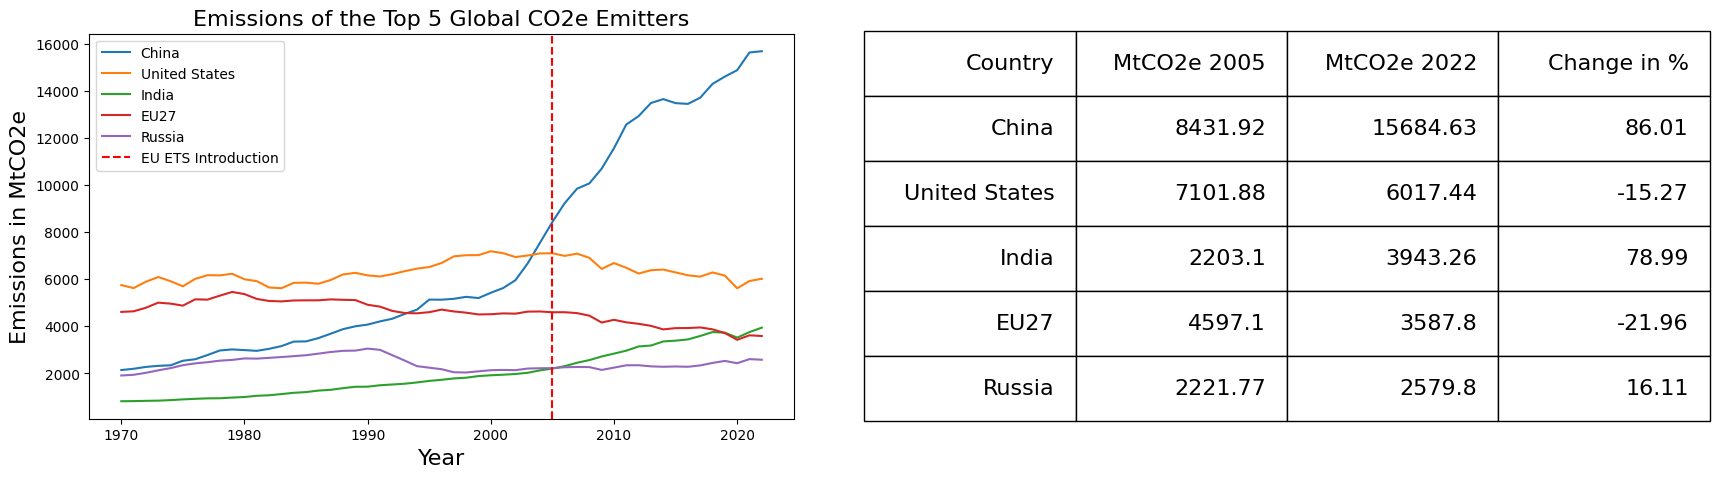

In [45]:
### PLOT FOR LATEX DOCUMENT

filtered_ghg_totals = global_ghg_emissions[global_ghg_emissions['Country'] != 'GLOBAL TOTAL']
big_five_indexer = filtered_ghg_totals[['Country', "1970", "2022"]].sort_values("2022", ascending=False).head(5)
big_five = global_ghg_emissions.loc[big_five_indexer.index].T
big_five.columns = big_five.iloc[1].values

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
big_five.iloc[2:, :].plot(
    ax=ax[0],
    kind='line', 
    title='Emissions of the Top 5 Global CO2e Emitters', 
    ylabel='Emissions in MtCO2e', 
    xlabel='Year'
)
ax[0].yaxis.get_label().set_fontsize(16)
ax[0].xaxis.get_label().set_fontsize(16)
ax[0].title.set_fontsize(16)
ax[0].axvline(35, color='r', label='EU ETS Introduction', ls='--')
ax[0].legend(loc="upper left")


head_5 = filtered_ghg_totals[['Country', "2005", "2022"]]
head_5['Change in %'] = (head_5["2022"] - head_5["2005"]) / head_5["2005"] * 100
big_five = head_5.sort_values("2022", ascending=False).dropna().head(5)
big_five["2005"] = big_five["2005"].round(2)
big_five["2022"] = big_five["2022"].round(2)
big_five["Change in %"] = big_five["Change in %"].round(2)

ax[1].axis('tight')
ax[1].axis('off')
table = ax[1].table(
    cellText=big_five.values, 
    loc='center', 
    colLabels=["Country","MtCO2e 2005", "MtCO2e 2022", "Change in %"],
    colLoc="right"
)
table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1.2, 3.9)

fig.savefig("global_top_5.pdf", format="pdf", bbox_inches="tight")